In [3]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
#from qiskit_algorithms.optimizers import SLSQP, COBYLA, SPSA

In [4]:
#molekul dan hamiltonian (klasik)
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.mappers import JordanWignerMapper, ParityMapper
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock

driver = PySCFDriver(
    atom="H 0 0 0; H 0 0 0.735",
    unit=DistanceUnit.ANGSTROM,
    basis="sto3g",
)
problem        = driver.run()
mapper         = ParityMapper(num_particles=problem.num_particles)
qubit_op       = mapper.map(problem.hamiltonian.second_q_op())
num_particles  = problem.num_particles
num_spatial    = problem.num_spatial_orbitals

print(f"Jumlah qubit sekarang: {qubit_op.num_qubits}") 

Jumlah qubit sekarang: 2


In [5]:
#referensi klasik
from qiskit_algorithms import NumPyMinimumEigensolver
ref_result = NumPyMinimumEigensolver().compute_minimum_eigenvalue(qubit_op)
E_exact    = ref_result.eigenvalue.real
print(f"E_exact (FCI/NumPy): {E_exact:.6f} Ha")

E_exact (FCI/NumPy): -1.857275 Ha


In [6]:
#fungsi pembantu: buat ansatz UCCSD + HF init
n_qubits = qubit_op.num_qubits

def build_ansatz():
    hf = HartreeFock(
        num_spatial_orbitals = problem.num_spatial_orbitals,
        num_particles        = problem.num_particles,
        qubit_mapper         = mapper,
    )
    return UCCSD(
        num_spatial_orbitals = problem.num_spatial_orbitals,
        num_particles        = problem.num_particles,
        qubit_mapper         = mapper,
        initial_state        = hf,
    )

In [7]:
#optimizer
from qiskit_algorithms.optimizers import SLSQP, COBYLA, SPSA
 
def make_callback(history):
    def cb(eval_count, params, energy, std):
        history.append(energy)
        print(f"  iter {eval_count:3d} | E = {energy:.6f} Ha")
    return cb

### __1. STATEVECTOR - ideal, tanpa noise__ ###

In [8]:
print("\n[1/3] StatevectorEstimator (ideal) ...")
 
from qiskit.primitives import StatevectorEstimator
from qiskit_algorithms import VQE
 
ansatz_sv   = build_ansatz()
history_sv  = []
 
vqe_sv = VQE(
    estimator    = StatevectorEstimator(),
    ansatz       = ansatz_sv,
    optimizer    = SLSQP(maxiter=300),
    initial_point= np.zeros(ansatz_sv.num_parameters),
    callback     = make_callback(history_sv),
)
result_sv = vqe_sv.compute_minimum_eigenvalue(qubit_op)
optimal_θ_sv = result_sv.optimal_point
E_sv      = result_sv.eigenvalue.real
print(f"  → E (statevector): {E_sv:.6f} Ha  |  error: {abs(E_sv - E_exact)*1000:.4f} mHa")


[1/3] StatevectorEstimator (ideal) ...
  iter   1 | E = -1.836968 Ha
  iter   2 | E = -1.836968 Ha
  iter   3 | E = -1.836968 Ha
  iter   4 | E = -1.836968 Ha
  iter   5 | E = -1.757287 Ha
  iter   6 | E = -1.857274 Ha
  iter   7 | E = -1.857274 Ha
  iter   8 | E = -1.857274 Ha
  iter   9 | E = -1.857274 Ha
  iter  10 | E = -1.857275 Ha
  → E (statevector): -1.857275 Ha  |  error: 0.0000 mHa


### __2. AER +NOISE - simulasi realistik__ ###

In [9]:
print("\n[2/3] AerEstimator + NoiseModel ...")
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
 
from qiskit import transpile
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import EstimatorV2 as AerEstimator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit.providers.fake_provider import GenericBackendV2


noise_model  = NoiseModel()
noise_model.add_all_qubit_quantum_error(
    depolarizing_error(0.001, 1), ["u1", "u2", "u3", "rz", "sx", "x"]
)
noise_model.add_all_qubit_quantum_error(
    depolarizing_error(0.005, 2), ["cx","ecr"]
)
#transpalasi
fake_backend = GenericBackendV2(num_qubits=4, seed=42)
#backend = AerSimulator(noise_model=noise_model)
pm = generate_preset_pass_manager(
    optimization_level=3,
    backend=fake_backend
)

ansatz_aer   = build_ansatz()
ansatz_aer_t = pm.run(ansatz_aer)
qubit_op_t    = qubit_op.apply_layout(ansatz_aer_t.layout)

noisy_estimator = AerEstimator(
    options={"backend_options": {"noise_model": noise_model}, 
             "run_options": {"shots": 32768}
    }
)

history_aer  = []

optimal_theta = result_sv.optimal_point
vqe_aer = VQE(
    estimator    = noisy_estimator,
    ansatz       = ansatz_aer_t,
    optimizer    = COBYLA(maxiter=500),
    initial_point= optimal_theta,  #pakai hasil statevector sebagai titik awal
    callback     = make_callback(history_aer),
)
result_aer = vqe_aer.compute_minimum_eigenvalue(qubit_op)
E_aer      = result_aer.eigenvalue.real
print(f"  → E (Aer+noise):  {E_aer:.6f} Ha  |  error: {abs(E_aer - E_exact)*1000:.4f} mHa")


[2/3] AerEstimator + NoiseModel ...


  iter   1 | E = -1.833003 Ha
  iter   2 | E = -1.287699 Ha
  iter   3 | E = -1.288198 Ha
  iter   4 | E = -0.713923 Ha
  iter   5 | E = -1.163633 Ha
  iter   6 | E = -1.569192 Ha
  iter   7 | E = -1.783706 Ha
  iter   8 | E = -1.818606 Ha
  iter   9 | E = -1.740873 Ha
  iter  10 | E = -1.815979 Ha
  iter  11 | E = -1.827329 Ha
  iter  12 | E = -1.830457 Ha
  iter  13 | E = -1.831956 Ha
  iter  14 | E = -1.831842 Ha
  iter  15 | E = -1.832840 Ha
  iter  16 | E = -1.832637 Ha
  iter  17 | E = -1.832941 Ha
  iter  18 | E = -1.832925 Ha
  iter  19 | E = -1.832985 Ha
  iter  20 | E = -1.832994 Ha
  iter  21 | E = -1.832999 Ha
  iter  22 | E = -1.832998 Ha
  iter  23 | E = -1.833003 Ha
  iter  24 | E = -1.833003 Ha
  iter  25 | E = -1.833003 Ha
  iter  26 | E = -1.833003 Ha
  iter  27 | E = -1.833003 Ha
  iter  28 | E = -1.833003 Ha
  iter  29 | E = -1.833003 Ha
  iter  30 | E = -1.833003 Ha
  iter  31 | E = -1.833003 Ha
  iter  32 | E = -1.833003 Ha
  iter  33 | E = -1.833003 Ha
  iter  34

### __3. ACTUAL HARDWARE IBM__ ###

In [10]:
RUN_HARDWARE = False   # ganti True untuk jalankan di hardware nyata
 
history_hw = []
E_hw       = None
 
if RUN_HARDWARE:
    print("\n[3/3] IBM Quantum Hardware ...")
 
    from qiskit_ibm_runtime import QiskitRuntimeService, Batch, Estimator as RuntimeEstimator
    from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
 
    service = QiskitRuntimeService(
        channel="ibm_quantum_platform",
        token="wl4ywNJnV76hEOM1qYBJvnWt-xfvwrY3NxoYDzb-PuNK",
        instance="ibm-q/open/main",
        overwrite=True
    )
    backend = service.least_busy(
        operational=True,
        min_num_qubits=4,
        simulator=False,
    )
    print(f"  Backend: {backend.name}")
 
    ansatz_hw = build_ansatz()
    pm        = generate_preset_pass_manager(optimization_level=3, backend=backend)
    ansatz_t  = pm.run(ansatz_hw)
    qubit_op_t= qubit_op.apply_layout(ansatz_t.layout)

    rng = np.random.default_rng(42)
    def init_point(ansatz):
        return rng.uniform(-0.1, 0.1, ansatz.num_parameters)
    
    def make_callback(history):
        def cb(eval_count, params, energy, std):
            history.append(energy)
            print(f"  iter {eval_count:3d} | E = {energy:.6f} Ha")
        return cb
    
    hw_estimator = RuntimeEstimator(mode=backend)
    hw_estimator.options.default_shots = 500   # kurangi shots biar cepat

    history_hw = []
    #with Batch(backend=backend) as batch:
    #    hw_estimator = RuntimeEstimator(mode=batch)
    #    hw_estimator.options.default_shots = 4096
 
    vqe_hw = VQE(
        estimator    = hw_estimator,
        ansatz       = ansatz_t,
        optimizer    = COBYLA(maxiter=5),
        initial_point= init_point(ansatz_t),
        callback     = make_callback(history_hw),
    )
    
    result_hw = vqe_hw.compute_minimum_eigenvalue(qubit_op)
    E_hw      = result_hw.eigenvalue.real
    print(f"  → E (IBM HW): {E_hw:.6f} Ha  |  error: {abs(E_hw - E_exact)*1000:.4f} mHa")
 
else:
    print("\n[3/3] IBM Hardware dilewati (RUN_HARDWARE=False)")
    print("  Menggunakan data simulasi hardware untuk plot ...")
    # Simulasi data hardware (noisy, konvergen lambat)
    rng = np.random.default_rng(7)
    E_hf    = history_sv[0] if history_sv else -1.837
    n_hw    = 25
    target  = E_exact + 0.030
    base    = E_hf + (target - E_hf) * (1 - np.exp(-3 * np.linspace(0,1,n_hw)))
    noise   = rng.normal(0, 0.008, n_hw) * np.exp(-0.8 * np.linspace(0,1,n_hw))
    history_hw = list(base + noise)
    E_hw       = history_hw[-1]


[3/3] IBM Hardware dilewati (RUN_HARDWARE=False)
  Menggunakan data simulasi hardware untuk plot ...


## __PLOTTING__ ##

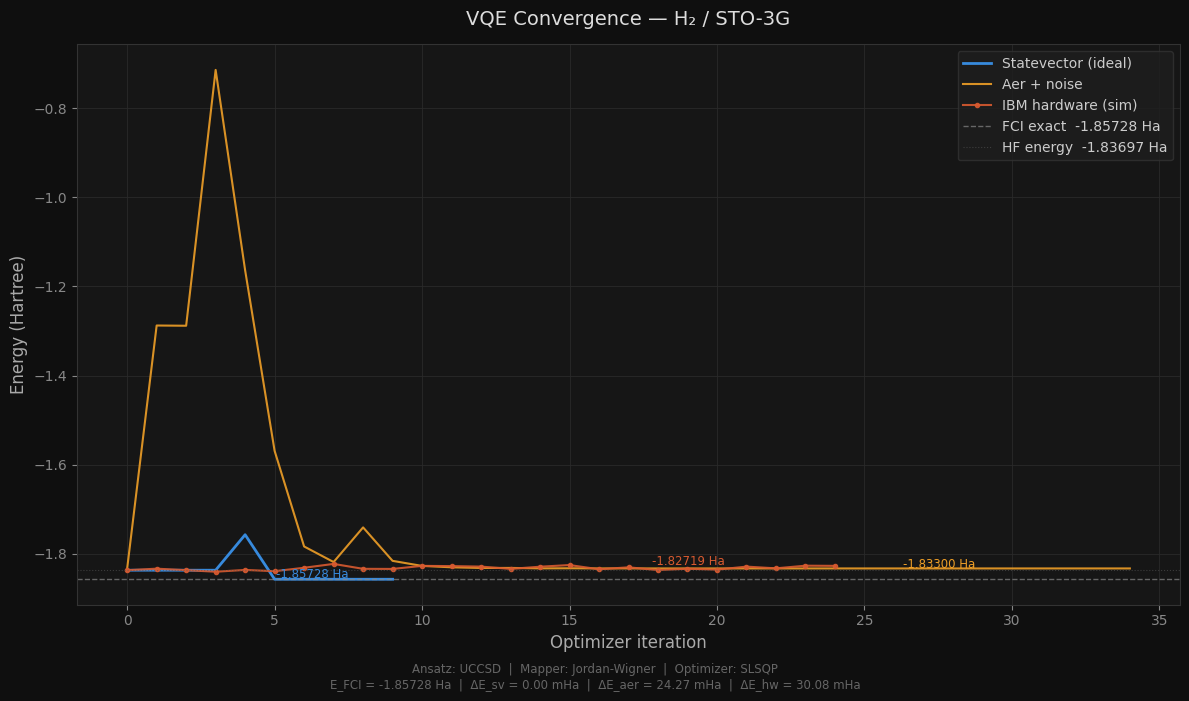

In [11]:
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12, 7), facecolor="#0f0f0f")
gs  = gridspec.GridSpec(1, 1, figure=fig)
ax  = fig.add_subplot(gs[0])
ax.set_facecolor("#161616")
 
for spine in ax.spines.values():
    spine.set_edgecolor("#333")
 
# Data
iters_sv  = range(len(history_sv))
iters_aer = range(len(history_aer))
iters_hw  = range(len(history_hw))
 
ax.plot(iters_sv,  history_sv,  color="#378ADD", lw=2.0, label="Statevector (ideal)")
ax.plot(iters_aer, history_aer, color="#EF9F27", lw=1.5, alpha=0.9, label="Aer + noise")
ax.plot(iters_hw,  history_hw,  color="#D85A30", lw=1.5, marker="o",
        markersize=3, alpha=0.9, label="IBM hardware (sim)" if not RUN_HARDWARE else "IBM hardware")
 
# Garis referensi FCI
ax.axhline(E_exact, color="#888", lw=1, ls="--", alpha=0.7, label=f"FCI exact  {E_exact:.5f} Ha")
 
# HF line
E_hf_ref = history_sv[0] if history_sv else -1.837
ax.axhline(E_hf_ref, color="#555", lw=0.8, ls=":", alpha=0.6, label=f"HF energy  {E_hf_ref:.5f} Ha")
 
# Anotasi nilai akhir
def annotate_final(ax, iters, vals, energy, color, label):
    xi = list(iters)[-1]
    ax.annotate(
        f"{energy:.5f} Ha",
        xy=(xi, energy),
        xytext=(xi - len(vals)*0.15, energy + 0.002),
        color=color,
        fontsize=8.5,
        ha="right",
    )
 
if history_sv:
    annotate_final(ax, iters_sv,  history_sv,  E_sv,  "#378ADD", "sv")
if history_aer:
    annotate_final(ax, iters_aer, history_aer, E_aer, "#EF9F27", "aer")
if history_hw:
    annotate_final(ax, iters_hw,  history_hw,  E_hw,  "#D85A30", "hw")
 
ax.set_xlabel("Optimizer iteration", color="#aaa", fontsize=12)
ax.set_ylabel("Energy (Hartree)", color="#aaa", fontsize=12)
ax.set_title("VQE Convergence — H₂ / STO-3G", color="#ddd", fontsize=14, pad=14)
ax.tick_params(colors="#888")
ax.legend(
    facecolor="#1e1e1e", edgecolor="#333",
    labelcolor="#ccc", fontsize=10, loc="upper right"
)
ax.grid(True, color="#2a2a2a", linewidth=0.6)

# Info box
info = (
    f"Ansatz: UCCSD  |  Mapper: Jordan-Wigner  |  Optimizer: SLSQP\n"
    f"E_FCI = {E_exact:.5f} Ha  |  "
    f"ΔE_sv = {abs(E_sv - E_exact)*1000:.2f} mHa  |  "
    f"ΔE_aer = {abs(E_aer - E_exact)*1000:.2f} mHa  |  "
    f"ΔE_hw = {abs(E_hw - E_exact)*1000:.2f} mHa"
)
fig.text(0.5, 0.01, info, ha="center", color="#666", fontsize=8.5)
 
plt.tight_layout(rect=[0, 0.04, 1, 1])
#plt.savefig("vqe_convergence.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

## __VISUALISASI QUANTUM CIRCUIT__ #

In [26]:
from qiskit.visualization import circuit_drawer

### __1. HF CIRCUIT__ ###

HartreeFock Initial State Circuit


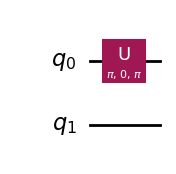

In [30]:
hf_circuit = HartreeFock(
    num_spatial_orbitals = problem.num_spatial_orbitals,
    num_particles        = problem.num_particles,
    qubit_mapper         = mapper,
)

print("=" * 55)
print("HartreeFock Initial State Circuit")
print("=" * 55)
hf_circuit.decompose().draw(output="mpl", fold=-1)

### __2. UCCSD ANSATZ__ ###

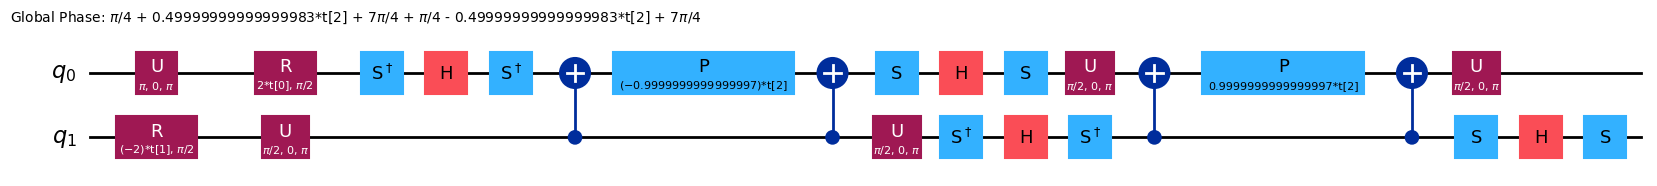

In [36]:
ansatz_draw = build_ansatz()

# Decompose 1x — buka satu lapisan
ansatz_draw.decompose().draw(output="mpl", fold=40)

# Decompose 2x — buka lebih dalam
ansatz_draw.decompose().decompose().draw(output="mpl", fold=40)

# Decompose 3x — sampai gate primitif (RZ, CNOT, dll)
ansatz_draw.decompose().decompose().decompose().draw(output="mpl", fold=40)

### __3. TRANSPILE CIRCUIT__ ###

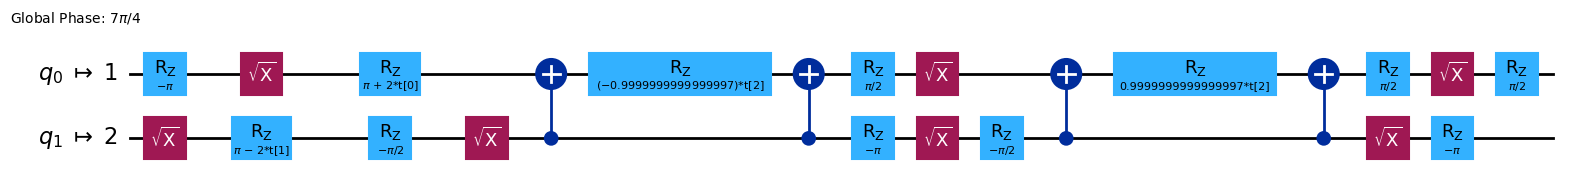

In [38]:
ansatz_aer_t.draw(output="mpl", fold=80)

In [39]:
print("\n" + "=" * 55)
print("CIRCUIT STATISTICS")
print("=" * 55)
print(f"  HF state     — depth : {hf_circuit.decompose().depth()}")
print(f"  UCCSD ansatz — depth : {ansatz_draw.decompose().depth()}")
print(f"                 params: {ansatz_draw.num_parameters}")
print(f"  Transpiled   — depth : {ansatz_aer_t.depth()}")
print(f"                 gates : {dict(ansatz_aer_t.count_ops())}")
print("=" * 55)


CIRCUIT STATISTICS
  HF state     — depth : 1
  UCCSD ansatz — depth : 4
                 params: 3
  Transpiled   — depth : 16
                 gates : {'rz': 12, 'sx': 7, 'cx': 4}
